This notebook uses the feature dataset generated in
01_INTRADAY_VOLATILITY_FORECASTING.ipynb.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.preprocessing import StandardScaler



df = pd.read_csv(
    "results/model_features.csv",
    index_col=0,
    parse_dates=True
)

df.head()

,range_5m,vol_20m,vol_10m,vol_5m,minute_of_day,future_vol_15m
date,,,,,,
2015-01-09 09:35:00,0.001183,0.000538,0.000492,0.000486,575,0.000518
2015-01-09 09:36:00,0.001183,0.000529,0.000452,0.000486,576,0.000531
2015-01-09 09:37:00,0.001504,0.000525,0.000458,0.000480,577,0.000494
2015-01-09 09:38:00,0.001503,0.000497,0.000491,0.000531,578,0.000478
2015-01-09 09:39:00,0.001503,0.000498,0.000459,0.000464,579,0.000481


In [26]:
features = [
    "range_5m",
    "vol_20m",
    "vol_10m",
    "vol_5m",
    "minute_of_day"
]

model_df = df[
    features +
    ["future_vol_15m"]
].dropna()

split = int(
    len(model_df) * 0.8
)

train = model_df.iloc[:split]
test = model_df.iloc[split:]

X_train = train[features]
y_train = train["future_vol_15m"]

X_test = test[features]
y_test = test["future_vol_15m"]

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [28]:
linear = LinearRegression()

linear.fit(
    X_train_scaled,
    y_train
)

linear_importance = pd.Series(
    np.abs(linear.coef_),
    index=features
).sort_values(
    ascending=False
)

linear_importance

range_5m         0.000134
vol_20m          0.000104
minute_of_day    0.000089
vol_5m           0.000065
vol_10m          0.000004
dtype: float64

In [29]:
ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_scaled,
    y_train
)

ridge_importance = pd.Series(
    np.abs(ridge.coef_),
    index=features
).sort_values(
    ascending=False
)

ridge_importance

range_5m         0.000134
vol_20m          0.000104
minute_of_day    0.000089
vol_5m           0.000065
vol_10m          0.000004
dtype: float64

In [30]:
comparison = pd.DataFrame(
    {
        "Linear":
        linear_importance,

        "Ridge":
        ridge_importance
    }
)

comparison

,Linear,Ridge
range_5m,0.000134,0.000134
vol_20m,0.000104,0.000104
minute_of_day,0.000089,0.000089
vol_5m,0.000065,0.000065
vol_10m,0.000004,0.000004


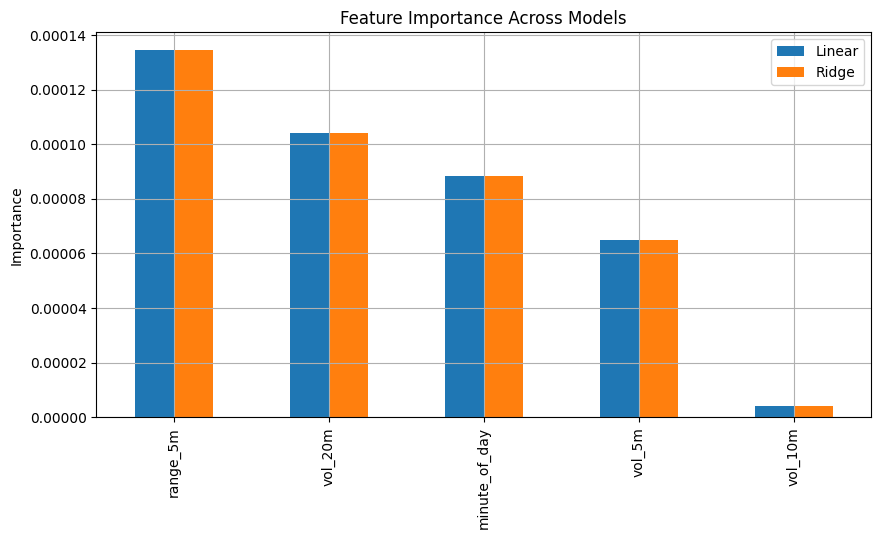

In [31]:
comparison.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Feature Importance Across Models"
)

plt.ylabel(
    "Importance"
)

plt.grid(True)

plt.savefig(
    "plots/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [32]:
comparison.to_csv(
    "results/model_comparison.csv"
)

linear_importance.to_csv(
    "results/linear_feature_importance.csv"
)

ridge_importance.to_csv(
    "results/ridge_feature_importance.csv"
)